In [1]:
experiment = "all_pixels_diff_pert_diff_eps"

import pandas as pd
CSV_PATH = f"../results/{experiment}/combined_results.csv"
df = pd.read_csv(CSV_PATH)

/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_57534/693068920.py:5: DtypeWarning: Columns (14,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


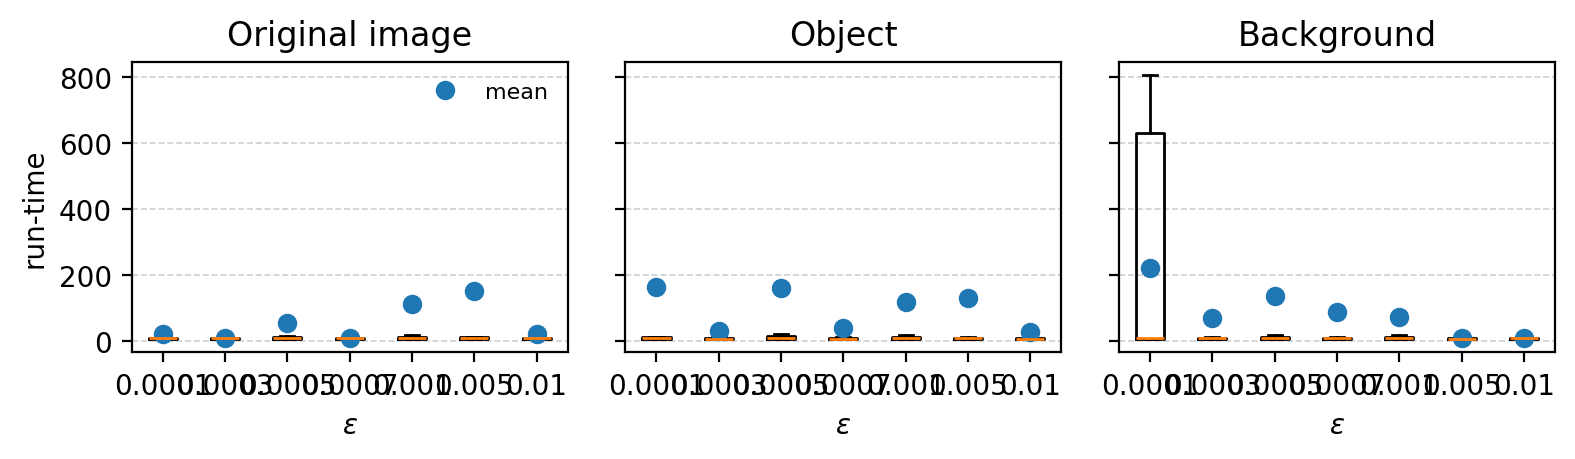

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)

    keep = pd.Series(True, index=frame.index)
    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def prep_data(sub: pd.DataFrame):
    sub = sub.copy()
    sub[TIME_COL] = pd.to_numeric(sub[TIME_COL], errors="coerce")
    sub = sub.dropna(subset=["eps", TIME_COL]).copy()

    eps_vals = sorted(sub["eps"].unique())
    data_per_eps = [sub.loc[sub["eps"] == eps, TIME_COL].values for eps in eps_vals]

    return eps_vals, data_per_eps

def boxplot_on_ax(ax, data_per_eps, eps_vals, title, show_legend=False):
    ax.boxplot(
        data_per_eps,
        tick_labels=[f"{e:g}" for e in eps_vals],
        showfliers=False,
        widths=0.45,   # thinner boxes
    )

    means = [np.mean(v) if len(v) else np.nan for v in data_per_eps]
    ax.plot(
        range(1, len(eps_vals) + 1),
        means,
        marker="o",
        linestyle="none",
        label="mean",
    )

    ax.set_xlabel(r"$\epsilon$")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    if show_legend:
        ax.legend(frameon=False, fontsize=8)

# ---------------------------
# Build subsets
# ---------------------------

# Original image (global)
if "is_global" in df.columns:
    df_orig = df[df["is_global"] == True].copy()
else:
    df_orig = filter_by_tag_contains(df, include_any=("global",))

# Object (segmented mask)
df_object = filter_by_tag_contains(
    df,
    include_all=("seg", "mask"),
    exclude_any=("non-mask", "nonmask", "non_mask"),
)

# Background (segmented non-mask)
df_background = filter_by_tag_contains(
    df,
    include_all=("seg",),
    include_any=("non-mask", "nonmask", "non_mask"),
)

# ---------------------------
# Prepare data
# ---------------------------
orig_eps, orig_data = prep_data(df_orig)
obj_eps, obj_data = prep_data(df_object)
bg_eps, bg_data = prep_data(df_background)

# ---------------------------
# Plot: 3 side-by-side figures
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.4), dpi=200, sharey=True)

axes[0].set_ylabel("run-time")

boxplot_on_ax(
    axes[0],
    orig_data,
    orig_eps,
    "Original image",
    show_legend=True,
)

boxplot_on_ax(
    axes[1],
    obj_data,
    obj_eps,
    "Object",
)

boxplot_on_ax(
    axes[2],
    bg_data,
    bg_eps,
    "Background",
)

plt.tight_layout();
plt.show();

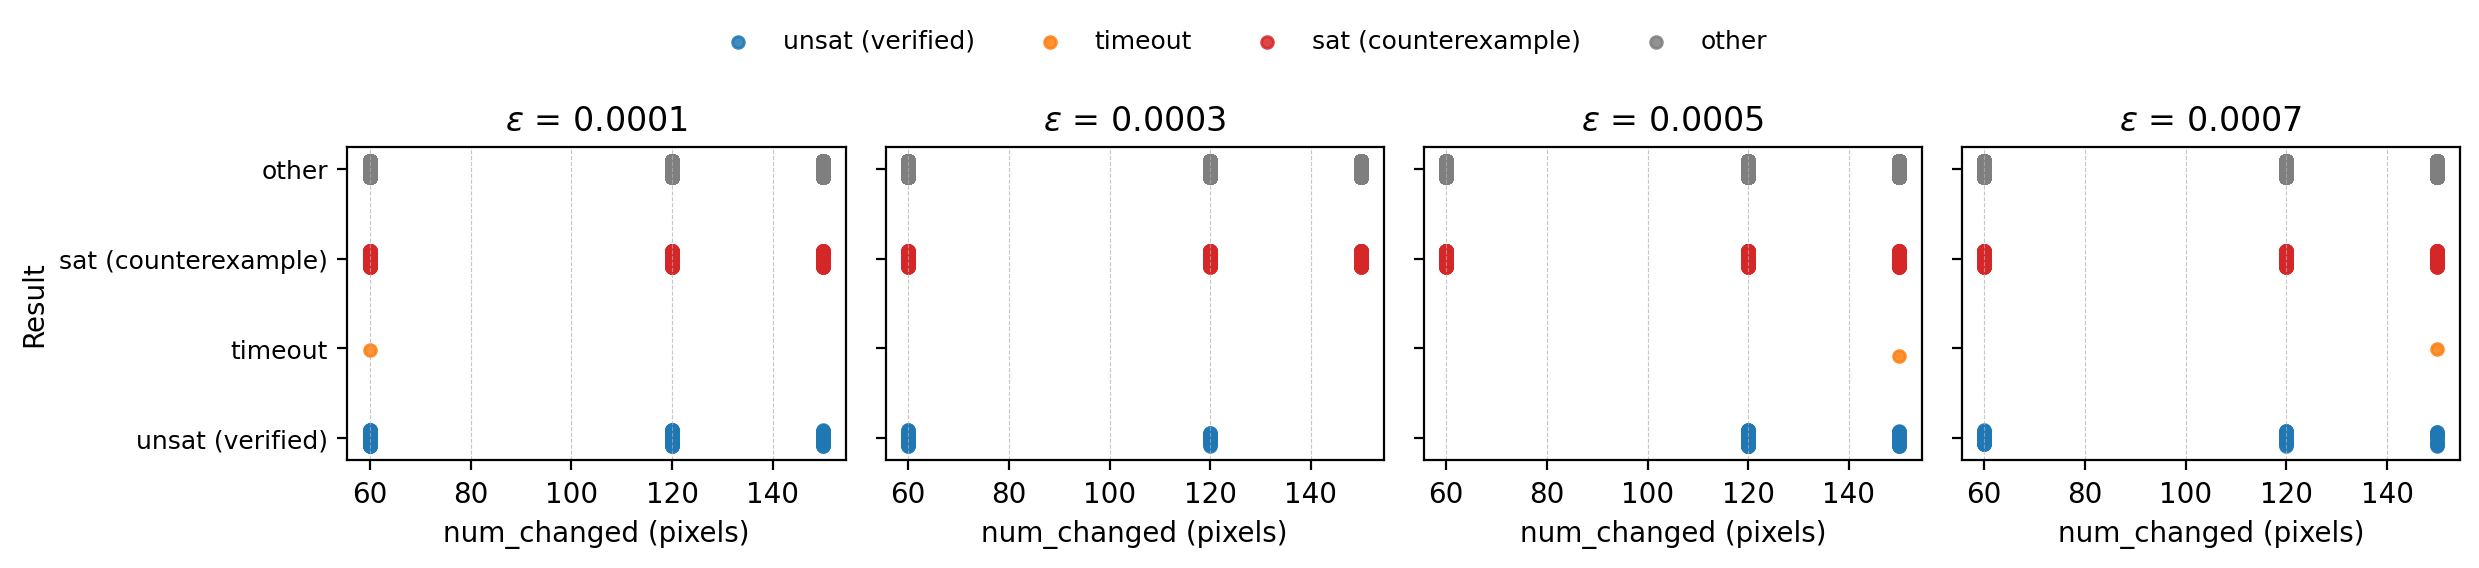

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_COL = "num_changed"   # <-- number of changed pixels
EPS_COL = "eps"
RES_COL = "result"

# ---------------------------------------
# 1) Map "result" column -> y categories
# ---------------------------------------
def map_result(r):
    if pd.isna(r):
        return "other"
    r = str(r).strip().lower()

    if r == "unsat false":
        return "unsat (verified)"
    if r == "sat true":
        return "sat (counterexample)"
    if r == "timeout false":
        return "timeout"
    return "other"

ORDER = [
    "unsat (verified)",
    "timeout",
    "sat (counterexample)",
    "other",
]

COLOR_MAP = {
    "unsat (verified)":     "#1f77b4",
    "timeout":              "#ff7f0e",
    "sat (counterexample)": "#d62728",
    "other":                "#7f7f7f",
}

# ---------------------------------------
# 2) Prep data
# ---------------------------------------
d = df.copy()
d[EPS_COL] = pd.to_numeric(d[EPS_COL], errors="coerce")
d[X_COL] = pd.to_numeric(d[X_COL], errors="coerce")

# Keep rows that have eps and num_changed
d = d.dropna(subset=[EPS_COL, X_COL]).copy()

# Map result categories ONLY from result column
d["y_cat"] = d[RES_COL].apply(map_result)

# Keep only categories that exist, but in fixed order
present = [c for c in ORDER if c in set(d["y_cat"].unique())]

# Numeric y positions for jitter
y_to_num = {c: i for i, c in enumerate(present)}
d["y_num"] = d["y_cat"].map(y_to_num)

# ---------------------------------------
# 3) 4 panels next to each other (one per eps)
# ---------------------------------------
eps_list = sorted(d[EPS_COL].dropna().unique())[:4]
fig, axes = plt.subplots(1, len(eps_list), figsize=(12.5, 2.8), dpi=200, sharey=True)
if len(eps_list) == 1:
    axes = [axes]

rng = np.random.default_rng(0)

for ax, eps in zip(axes, eps_list):
    sub = d[d[EPS_COL] == eps].copy()
    if sub.empty:
        ax.set_title(rf"$\epsilon$={eps:g}" + "\n(no data)")
        ax.axis("off")
        continue

    # Jitter the y positions a bit
    y_num = sub["y_num"].astype(float).to_numpy()
    y_jitter = y_num + (rng.random(len(y_num)) - 0.5) * 0.18

    x = sub[X_COL].to_numpy()

    for cat in present:
        mask = (sub["y_cat"] == cat).to_numpy()
        if not mask.any():
            continue
        ax.scatter(
            x[mask], y_jitter[mask],
            s=18, alpha=0.85,
            color=COLOR_MAP.get(cat, "#7f7f7f"),
            label=cat
        )

    ax.set_title(rf"$\epsilon$ = {eps:g}", fontsize=12)
    ax.set_xlabel("num_changed (pixels)")
    # If your num_changed spans a huge range (e.g., 2..5000), uncomment:
    # ax.set_xscale("log")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.7)

# y-axis labels = results
axes[0].set_ylabel("Result")
axes[0].set_yticks(range(len(present)))
axes[0].set_yticklabels(present, fontsize=9)

# One legend for the whole figure (deduplicate)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(),
    loc="upper center",
    ncol=min(6, len(by_label)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

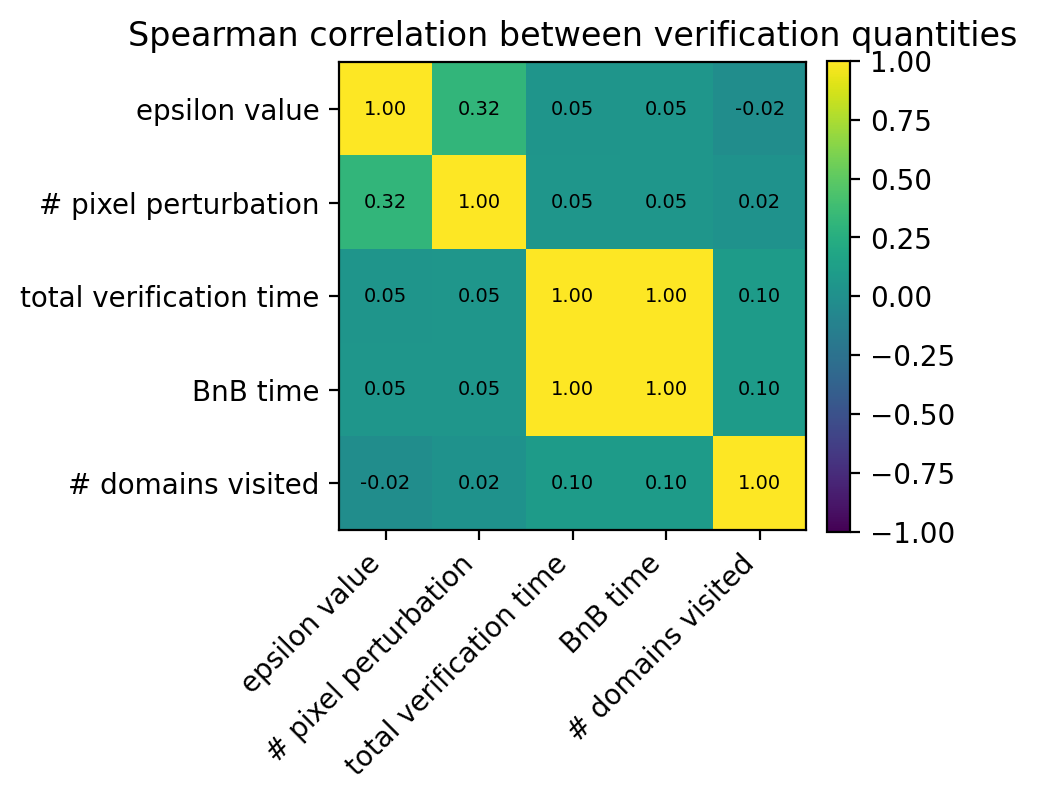

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Select numeric columns
# ---------------------------------------
candidate_cols = [
    "eps",
    "percent_changed",
    "all_time",
    "bab_time",
    "domains_visited",
]

num_cols = [c for c in candidate_cols if c in df.columns]

# Convert to numeric safely
d = df[num_cols].apply(pd.to_numeric, errors="coerce")
d = d.dropna(how="any")

# ---------------------------------------
# Compute correlation (Spearman)
# ---------------------------------------
corr = d.corr(method="spearman")

# ---------------------------------------
# Pretty labels (DISPLAY ONLY)
# ---------------------------------------
LABEL_MAP = {
    "eps": "epsilon value",
    "percent_changed": "# pixel perturbation",
    "all_time": "total verification time",
    "bab_time": "BnB time",
    "domains_visited": "# domains visited",
}

corr = corr.rename(index=LABEL_MAP, columns=LABEL_MAP)

# ---------------------------------------
# Plot correlation heatmap
# ---------------------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=200)

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Annotate correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

# ✅ title WITHOUT "percentage change only"
ax.set_title("Spearman correlation between verification quantities")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Verification cost correlates with perturbation size and search effort, not with ε.

Rows total (paired keys): 1330
Rows fully paired (have all 3 variants): 841


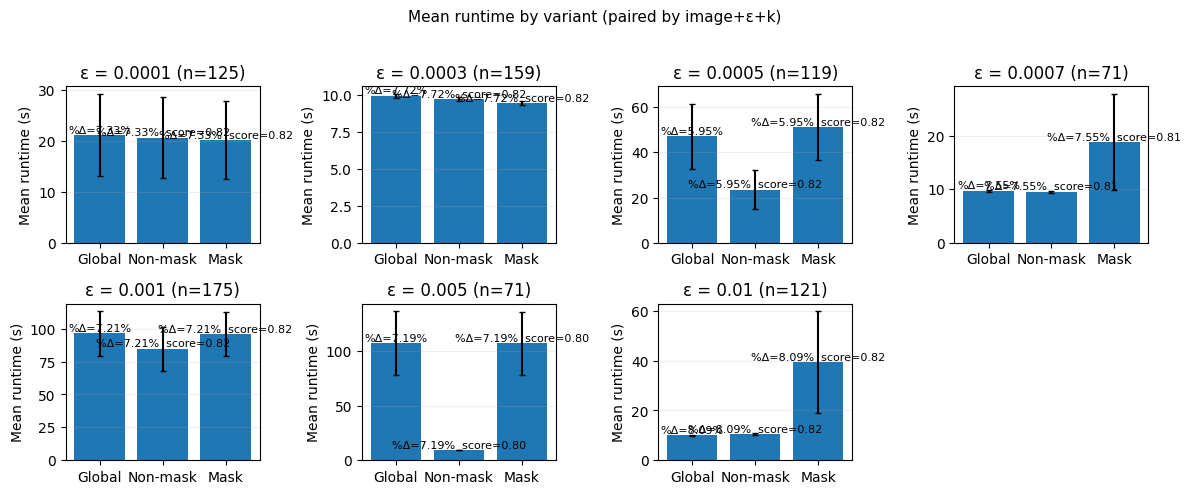

In [5]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
CSV_PATH = "/path/to/your.csv"   # <-- EDIT
TIME_COL = "all_time"           # or "bab_time"
PAIR_ON_K = True               # pair by (image, eps, k). If you want only (image, eps), set False.

VARIANTS = ["Global", "Seg-0 (Non-mask)", "Seg-0 (Mask)"]
XTICK_LABELS = ["Global", "Non-mask", "Mask"]

# =========================
# HELPERS
# =========================
def _eps_grid(eps_values, max_cols=4):
    n = len(eps_values)
    cols = min(max_cols, n) if n > 0 else 1
    rows = int(math.ceil(n / cols)) if n > 0 else 1
    return rows, cols

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))

def _annotate_bar(ax, j, height, text):
    ax.text(j, height, text, ha="center", va="bottom", fontsize=8)

def classify_variant(row) -> str:
    """
    Decide which of the 3 variants a row belongs to,
    based on your CSV columns: pattern, is_global, segment_index, tag, vnnlib.

    Adjust the mapping here if your pattern strings differ.
    """
    pat = str(row.get("pattern", "")).lower()
    is_global = bool(row.get("is_global", False))
    seg_idx = row.get("segment_index", None)

    # 1) Global is unambiguous
    if is_global or pat == "global" or "_global" in str(row.get("tag", "")).lower():
        return "Global"

    # 2) Non-mask vs Mask from pattern keywords
    # Common naming: fix_nonmask / nonmask / bg / background
    if any(k in pat for k in ["nonmask", "fix_nonmask", "bg", "background", "fix-nonmask", "non-mask"]):
        return "Seg-0 (Non-mask)"

    # Common naming: fix_mask / mask / obj / object / foreground
    if any(k in pat for k in ["fix_mask", "mask", "obj", "object", "foreground", "fix-mask"]):
        return "Seg-0 (Mask)"

    # 3) Fallback: if it's segmented but pattern is vague, try tag/vnnlib
    s = (str(row.get("tag", "")) + " " + str(row.get("vnnlib", ""))).lower()
    if any(k in s for k in ["nonmask", "non-mask", "fixnonmask", "fix_nonmask", "bg", "background"]):
        return "Seg-0 (Non-mask)"
    if any(k in s for k in ["fixmask", "fix_mask", "mask", "obj", "object", "foreground"]):
        return "Seg-0 (Mask)"

    # If still unknown, return None so we can drop it
    return None

# =========================
# LOAD
# =========================

# ensure numeric
for col in ["eps", "k", TIME_COL, "percent_changed", "score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# build variant
df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# OPTIONAL: if you only want Seg-0 (segment_index==0) for non-global rows
# (Global rows have segment_index == -1 in your sample)
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# =========================
# PAIRING KEY = (image, eps, k) or (image, eps)
# =========================
index_cols = ["image", "eps"] + (["k"] if (PAIR_ON_K and "k" in df.columns) else [])

# =========================
# WIDE TABLES (runtime + pct + score)
# =========================
# Runtime wide
time_wide = df.pivot_table(
    index=index_cols,
    columns="variant",
    values=TIME_COL,
    aggfunc="mean"   # if duplicates, average them
).reset_index()

# Percent wide (suffix _pct)
pct_wide = None
if "percent_changed" in df.columns:
    pct_wide = df.pivot_table(
        index=index_cols,
        columns="variant",
        values="percent_changed",
        aggfunc="mean"
    ).reset_index()
    for v in VARIANTS:
        if v in pct_wide.columns:
            pct_wide = pct_wide.rename(columns={v: f"{v}_pct"})

# Score wide (suffix _score)
score_wide = None
if "score" in df.columns:
    score_wide = df.pivot_table(
        index=index_cols,
        columns="variant",
        values="score",
        aggfunc="mean"
    ).reset_index()
    for v in VARIANTS:
        if v in score_wide.columns:
            score_wide = score_wide.rename(columns={v: f"{v}_score"})

# Merge into all3 (paired table)
all3 = time_wide
if pct_wide is not None:
    all3 = all3.merge(pct_wide, on=index_cols, how="left")
if score_wide is not None:
    all3 = all3.merge(score_wide, on=index_cols, how="left")

# =========================
# (Optional) Keep only "fully paired" rows (all 3 variants exist)
# =========================
# Comment this block out if you want to include partial pairs.
need_cols = [v for v in VARIANTS if v in all3.columns]
all3_full = all3.dropna(subset=need_cols).copy()

print("Rows total (paired keys):", len(all3))
print("Rows fully paired (have all 3 variants):", len(all3_full))

# Use fully paired for plotting
plot_df = all3_full

# =========================
# PLOT (your exact plot structure)
# =========================
eps_values = sorted(plot_df["eps"].dropna().unique())
rows, cols = _eps_grid(eps_values, max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*2.4), squeeze=False)

xpos = np.arange(len(VARIANTS))

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]

    sub = plot_df[plot_df["eps"] == eps]

    means = [sub[v].mean() if v in sub.columns else np.nan for v in VARIANTS]
    sems  = [_sem(sub[v].values) if v in sub.columns else np.nan for v in VARIANTS]

    ax.bar(xpos, means, yerr=sems, capsize=2)
    ax.set_xticks(xpos)
    ax.set_xticklabels(XTICK_LABELS, rotation=0)
    ax.set_title(f"ε = {eps:g} (n={len(sub)})")
    ax.set_ylabel("Mean runtime (s)")
    ax.grid(True, axis="y", alpha=0.2)

    # annotations: mean percent_changed + score where available
    for j, v in enumerate(VARIANTS):
        pct_col = f"{v}_pct"
        sc_col  = f"{v}_score"

        pct_mean = sub[pct_col].mean() if pct_col in sub.columns else np.nan
        sc_mean  = sub[sc_col].mean() if sc_col in sub.columns else np.nan

        label_parts = []
        if not np.isnan(pct_mean):
            # percent_changed in your CSV looks like fraction (0..1)
            label_parts.append(f"%Δ={pct_mean*100:.2f}%")
        if v != "Global" and not np.isnan(sc_mean):
            label_parts.append(f"score={sc_mean:.2f}")

        if label_parts and not np.isnan(means[j]):
            _annotate_bar(ax, j, means[j], "  ".join(label_parts))

# Hide unused subplots
for j in range(len(eps_values), rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

pair_note = "image+ε+k" if (PAIR_ON_K and "k" in df.columns) else "image+ε"
fig.suptitle(f"Mean runtime by variant (paired by {pair_note})", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

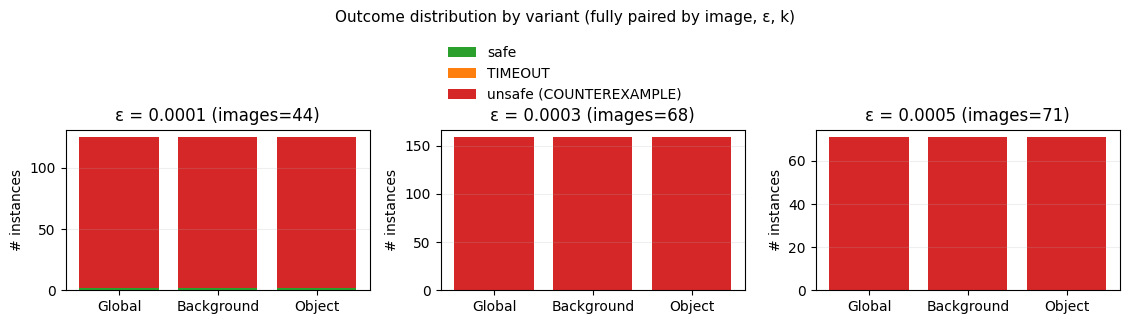

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PAIR_COLS = ["image", "eps", "k"]

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]
MAX_COLS = 4

# -----------------------------
# RESULT LABEL NORMALIZATION
# -----------------------------
RESULT_RENAME = {
    "unsat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}

RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",  # red
    "safe": "#2ca02c",                     # green
    "TIMEOUT": "#ff7f0e",                  # orange
}

# Order in legend / stacking
RESULT_ORDER = [
    "safe",
    "TIMEOUT",
    "unsafe (COUNTEREXAMPLE)",
]

# -----------------------------
# LOAD
# -----------------------------

df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)

# -----------------------------
# VARIANT CLASSIFIER (correct semantics)
# FixMask    -> Background
# FixNonMask -> Object
# -----------------------------
def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])

    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask"]):
        return "Object"

    if any(k in s for k in ["background", "bg", "nonmask", "non-mask"]):
        return "Background"
    if any(k in s for k in ["mask", "object", "obj", "foreground"]):
        return "Object"

    return None

df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Keep only seg0 for non-global
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# -----------------------------
# CLEAN RESULT LABELS
# -----------------------------
df = df[df["result"].isin(RESULT_RENAME)].copy()
df["result_clean"] = df["result"].map(RESULT_RENAME)

# -----------------------------
# PAIRED WIDE TABLE
# -----------------------------
res_all3 = df.pivot_table(
    index=PAIR_COLS,
    columns="variant",
    values="result_clean",
    aggfunc="first"
).reset_index()

# ONLY fully paired
res_all3 = res_all3.dropna(subset=VARIANTS).copy()

# -----------------------------
# PLOT
# -----------------------------
eps_values = sorted(res_all3["eps"].dropna().unique())
cols = min(MAX_COLS, max(1, len(eps_values)))
rows = math.ceil(len(eps_values) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 3.8, rows * 2.9),
    squeeze=False
)

x = np.arange(len(VARIANTS))

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    sub = res_all3[res_all3["eps"] == eps]

    n_images = sub["image"].nunique()
    bottom = np.zeros(len(VARIANTS), dtype=float)

    for lab in RESULT_ORDER:
        vals = np.array([(sub[v] == lab).sum() for v in VARIANTS], dtype=float)
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=lab,
            color=RESULT_COLORS[lab]
        )
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(XTICK_LABELS)
    ax.set_title(f"ε = {eps:g} (images={n_images})")
    ax.set_ylabel("# instances")
    ax.grid(True, axis="y", alpha=0.2)

# Hide unused axes
for j in range(len(eps_values), rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

# Legend (readable)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=1,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Outcome distribution by variant (fully paired by image, ε, k)",
    y=1.10,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


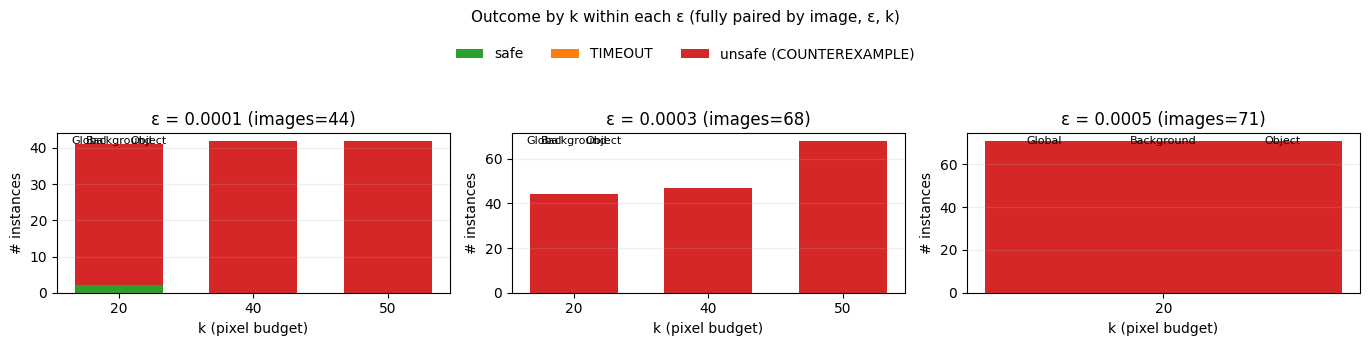

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Assumes you already have:
# res_all3 : wide table with columns ["image","eps","k","Global","Background","Object"]
# VARIANTS = ["Global","Background","Object"]
# RESULT_ORDER = ["safe","TIMEOUT","unsafe (COUNTEREXAMPLE)"]
# RESULT_COLORS = {...}

def _eps_grid(eps_values, max_cols=4):
    n = len(eps_values)
    cols = min(max_cols, max(1, n))
    rows = math.ceil(n / cols)
    return rows, cols

eps_values = sorted(res_all3["eps"].dropna().unique())
k_values_all = sorted(res_all3["k"].dropna().unique())

max_cols = 4
rows, cols = _eps_grid(eps_values, max_cols=max_cols)

# width tuning
bar_w = 0.22            # width of each variant bar inside a k-group
gap_k = 0.35            # extra spacing between k-groups

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.6, rows * 3.1), squeeze=False)

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    sub_eps = res_all3[res_all3["eps"] == eps].copy()

    # only k values present for this eps
    k_values = sorted(sub_eps["k"].dropna().unique())
    if len(k_values) == 0:
        ax.axis("off")
        continue

    # x positions: one group per k, with 3 bars (Global/Background/Object) per group
    group_x = np.arange(len(k_values)) * (3 * bar_w + gap_k)
    offsets = np.array([-bar_w, 0.0, bar_w])  # for 3 variants

    # Plot stacked outcomes for each variant bar
    for vi, variant in enumerate(["Global", "Background", "Object"]):
        x = group_x + offsets[vi]
        bottom = np.zeros(len(k_values), dtype=float)

        for lab in RESULT_ORDER:
            vals = []
            for kk in k_values:
                sub = sub_eps[sub_eps["k"] == kk]
                vals.append(float((sub[variant] == lab).sum()))
            vals = np.array(vals, dtype=float)

            ax.bar(
                x, vals,
                width=bar_w,
                bottom=bottom,
                color=RESULT_COLORS[lab],
                label=lab if (idx == 0 and vi == 0) else None  # legend once
            )
            bottom += vals

    # x tick per k-group
    ax.set_xticks(group_x)
    ax.set_xticklabels([str(int(k)) if float(k).is_integer() else str(k) for k in k_values], rotation=0)
    ax.set_xlabel("k (pixel budget)")

    n_images = sub_eps["image"].nunique()
    ax.set_title(f"ε = {eps:g} (images={n_images})")
    ax.set_ylabel("# instances")
    ax.grid(True, axis="y", alpha=0.2)

    # small annotation for which bar is which
    # Put variant labels near the first k-group
    if len(k_values) > 0:
        y0 = ax.get_ylim()[1] * 0.98
        for vi, name in enumerate(["Global","Background","Object"]):
            ax.text(group_x[0] + offsets[vi], y0, name, ha="center", va="top", fontsize=8)

# Hide unused axes
for j in range(len(eps_values), rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

# Legend
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("Outcome by k within each ε (fully paired by image, ε, k)", y=1.10, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

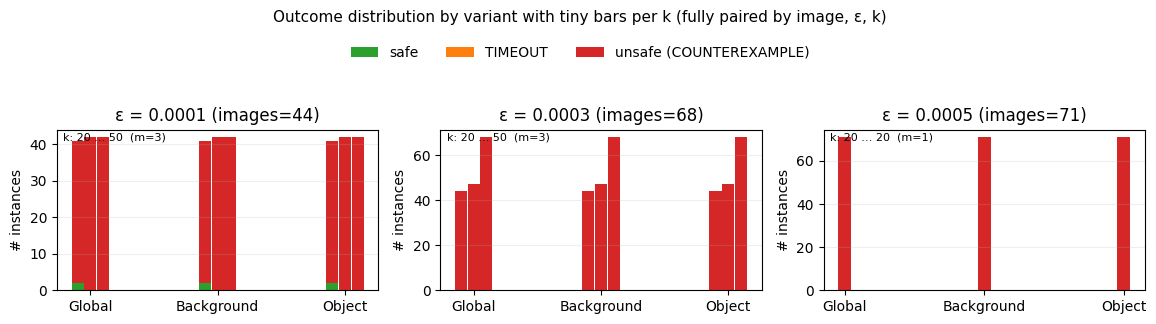

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Assumes:
#   res_all3 columns: ["image","eps","k","Global","Background","Object"]
#   values in Global/Background/Object are:
#       "safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"
# -------------------------------------------------

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]

RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]
RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",  # red
    "safe": "#2ca02c",                     # green
    "TIMEOUT": "#ff7f0e",                  # orange
}

MAX_COLS = 4

def _eps_grid(eps_values, max_cols=4):
    n = len(eps_values)
    cols = min(max_cols, max(1, n))
    rows = math.ceil(n / cols)
    return rows, cols

eps_values = sorted(res_all3["eps"].dropna().unique())
rows, cols = _eps_grid(eps_values, max_cols=MAX_COLS)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.9, rows * 2.9), squeeze=False)

# Base x positions for the 3 variants
base_x = np.arange(len(VARIANTS), dtype=float)

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]

    sub_eps = res_all3[res_all3["eps"] == eps].copy()
    k_values = sorted(sub_eps["k"].dropna().unique())

    n_images = sub_eps["image"].nunique()

    # --- tiny-bar geometry within each variant slot ---
    # We place k bars in a compact band around each base_x[v].
    # total band width ~ 0.75 (so it fits nicely without overlapping neighbors)
    band = 0.75
    m = len(k_values)

    if m == 0:
        ax.axis("off")
        continue

    # tiny bar width + offsets centered around 0
    tiny_w = min(0.10, band / max(m, 1))          # cap width so it stays "tiny"
    offsets = (np.arange(m) - (m - 1) / 2.0) * tiny_w

    # Plot: for each variant, draw m tiny stacked bars (one per k)
    for vi, variant in enumerate(VARIANTS):
        x_positions = base_x[vi] + offsets
        bottom = np.zeros(m, dtype=float)

        # For each outcome class, stack counts per k
        for lab in RESULT_ORDER:
            vals = []
            for kk in k_values:
                sub_k = sub_eps[sub_eps["k"] == kk]
                vals.append(float((sub_k[variant] == lab).sum()))
            vals = np.array(vals, dtype=float)

            ax.bar(
                x_positions,
                vals,
                width=tiny_w * 0.95,
                bottom=bottom,
                color=RESULT_COLORS[lab],
                label=lab if (idx == 0 and vi == 0) else None,  # legend once
                linewidth=0
            )
            bottom += vals

    # Axis formatting
    ax.set_xticks(base_x)
    ax.set_xticklabels(XTICK_LABELS)
    ax.set_title(f"ε = {eps:g} (images={n_images})")
    ax.set_ylabel("# instances")
    ax.grid(True, axis="y", alpha=0.2)

    # Optional: show min/max k to remind what those tiny bars represent (keeps it clean)
    kmin, kmax = (k_values[0], k_values[-1])
    ax.text(
        0.02, 0.98,
        f"k: {kmin:g} … {kmax:g}  (m={m})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=8
    )

# Hide unused axes
for j in range(len(eps_values), rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

# Legend (readable, horizontal)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle("Outcome distribution by variant with tiny bars per k (fully paired by image, ε, k)", y=1.10, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()